In [ ]:
import torch
import numpy as np
import pickle
from os import listdir
import matplotlib.pyplot as plt
from tqdm.notebook import tqdm

from autoencoder import autoencoder, build_autoencoder


In [ ]:
def open_object(file_name):
        """
        # open_object

        open_object(file_name)

        Open a file using the Pickle library. 
        Is used in this context for files containing dictionaries.

        Parameters
        ----------
        - file_name : str
                - Name of the file to open.

        Returns
        -------
        None
        """
        try:
            with open(file_name, 'rb') as f:
                dictionary = pickle.load(f)
        except Exception as ex:
            print("Error when loading file : ", ex)

        return dictionary

In [ ]:
def build_dataset(path,size):
    """
    build_dataset(path)

        Import dataset from path, normalize data and separate in train and test datasets.

        -path (str) : Path to the dataset files. 
    """
    X = np.concatenate([np.fromfile(f"{path}{fileName}",dtype=np.float16).reshape(-1,size) for fileName in listdir(path)])
    shape = np.shape(X)

    #X = (X - np.mean(X)) / (np.std(X))
    
    return X

### Load dataset

In [ ]:
X = build_dataset(f"Datasets/NIST (250)/", 250)

### Load model 

In [ ]:
date_time = "run-2023-07-17-15-15/fold 0"
path_save = f"Autoencoder Log/{date_time}/"

config = open_object(f"{path_save}/log.bin")


### Build model using build_autoencoder class

In [ ]:
experiment = autoencoder()
model = build_autoencoder
network = model(config)

network.load_state_dict(torch.load(f"{path_save}model.pt"))
network.eval()

build_autoencoder(
  (encoder): Sequential(
    (0): Linear(in_features=250, out_features=50, bias=True)
    (1): GELU(approximate='none')
    (2): Linear(in_features=50, out_features=1, bias=True)
    (3): PReLU(num_parameters=1)
  )
  (decoder): Sequential(
    (0): Linear(in_features=1, out_features=50, bias=True)
    (1): GELU(approximate='none')
    (2): Linear(in_features=50, out_features=250, bias=True)
  )
)

### Definition of initial uncertainty

- The uncertainty in the location of the centre of the distribution is given by α, the standard error of the mean. The error decreases (slowly) with more measurements:

$$
\alpha = \frac{\sigma_{N-1}}{\sqrt{N}}
$$

- The result of repeated measurements is reported as $\bar{x} \pm \alpha$.

Text(0, 0.5, 'Counts')

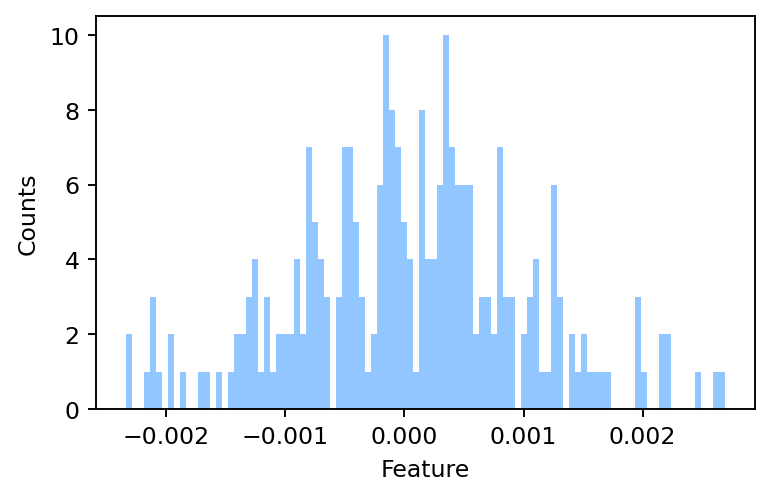

In [ ]:
sigma_voltage = 1e-3
N = 1
alpha_voltage = sigma_voltage / np.sqrt(N)

signal_size = np.shape(X)[1]
signal_nb = int(1e3)#np.shape(X)[0]

#init_distribution = np.random.poisson(alpha_voltage, signal_size * signal_nb).reshape(signal_nb,signal_size)
init_distribution = np.random.normal(scale=sigma_voltage, size=signal_nb * signal_size).reshape(signal_nb,signal_size)

plt.figure(figsize=(5,3), dpi=170)
plt.hist(init_distribution[0], bins=100)

plt.xlabel("Feature")
plt.ylabel("Counts")

In [ ]:
alpha_network = []

for index, x in tqdm(enumerate(X)):
    x_pytorch = torch.from_numpy(init_distribution + x).view(-1, 1, 250).float()
    prop_distribution = network(x_pytorch, encoding=True).detach().numpy().reshape(-1)
    alpha_network.append(np.std(prop_distribution) / np.sqrt(signal_nb))

plt.figure(figsize=(5,3), dpi=170)
plt.hist(alpha_network, bins=500)

plt.xlabel("Feature")
plt.ylabel("Counts")

  0%|          | 0/143360 [00:00<?, ?it/s]